Author - Vihara Thejaka Kularathna

Peer Reviewer - Muhammed Abdullah


*   Well commented- each code cell clearly explain the intention and funtion of every step
*   tutorial codes use throughout - All code blocks are leveraged and reused from tutorials


*   All the models are implemented successfully






Importing required libraries

In [1]:
#import pandas for data manipulation
import pandas as pd
# numpy foe numerical operations
import numpy as np
#matplotlib for decision trees
from matplotlib import pyplot as plt
#ploty express for interactive visualization
import plotly.express as px

**Seminar 7 page 2**

Loading the prepared classification dtaset saved from notebook 1 into a pandas data frame name df with the use of pd.read_csv() and displaying the first 5 rows

In [2]:
#loading the prepared clasification dataset
df = pd.read_csv('/content/Prepared_Classification_Dataset.csv')

#displaying the first 5 rows of the dataset
df.head()

,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,4,125000.0,0,1.0,4,21000,6.99,0.17,0,16,0
1,40.0,4,120000.0,2,4.0,0,20000,15.95,0.17,0,15,0
2,40.0,4,60000.0,0,13.0,2,20000,14.54,0.33,0,14,0
3,40.0,4,80000.0,2,10.0,4,20000,18.62,0.25,0,14,0
4,40.0,4,72000.0,3,3.0,2,20000,13.47,0.28,0,16,0


**Seminar 7 page 3**

Separates the dataset into features X by dropping out the target column loan approval status and assigning the target variable to Y. Moreover prints the list of input features name using list(X)

In [3]:
#Removing other depedent variable due to data leakage
X = df.drop(['loan_approval_status'], axis=1)
y = df['loan_approval_status']
list(X)

['age',
 'education_qualifications',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length']

**Seminar 3 page 8**

applying standard scaler for standarize all input features to zero mean and unit variance using fit_transform()

In [4]:
#importing standard scaler
from sklearn.preprocessing import StandardScaler
#putting standard scaling to the input features
scaler = StandardScaler()
X1 = scaler.fit_transform(X)


# splitting data set into training and test sets
**Seminar 7 page 3**

splitting the scaleed dataset into 75% trainning and 25% test subsit by using train_test_split() with random_state=0 for ensure reproducability

In [5]:
#import train test split
from sklearn.model_selection import train_test_split
#splitting the dataset into train and test subsets
X1_train, X1_test, y_train, y_test = train_test_split(X1, y,
                                                  test_size=0.25,
                                                  random_state=0)

print('whole data shape', df.shape)
print('X1_train shape', X1_train.shape)
print('X1_test shape', X1_test.shape)

whole data shape (53605, 12)
X1_train shape (40203, 11)
X1_test shape (13402, 11)


# Making two base learners (KNN and LR)

**i choosed Logistic regression and KNN as the two base learners as they both are best performing base learners out of three **

**Seminar 4 page 7**

Instatiates and fit KNN clasifier with K=9 the value optimal value identified in Notebook2, on the training data and performs predictions on the test data.

In [6]:
#import KNeighbour clasiffier
from sklearn.neighbors import KNeighborsClassifier

#making a KNN classifier k=9
knn = KNeighborsClassifier(n_neighbors=9)

#fitting out the classifier into trainning data
knn.fit(X1_train, y_train)

#finding predictions on test data
y_pred_knn = knn.predict(X1_test)

**Seminar 4 page 8**

Creating thr confusion metrix for the KNN base learner

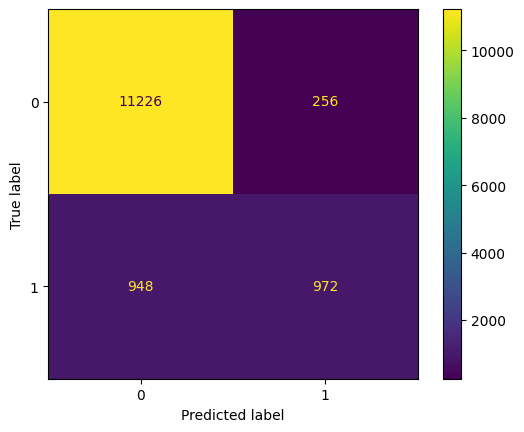

In [7]:
#import confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#creating the confusion metrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
#display the KNN confusion metrix
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)

disp_knn.plot()

**Seminar 4 page 8**

Clasification report for the KNN base learner

In [8]:
from sklearn.metrics import classification_report
#classfication report for KNN
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     11482
           1       0.79      0.51      0.62      1920

    accuracy                           0.91     13402
   macro avg       0.86      0.74      0.78     13402
weighted avg       0.90      0.91      0.90     13402



**Seminar 4 page 8**

ROC curve for the knn base learner

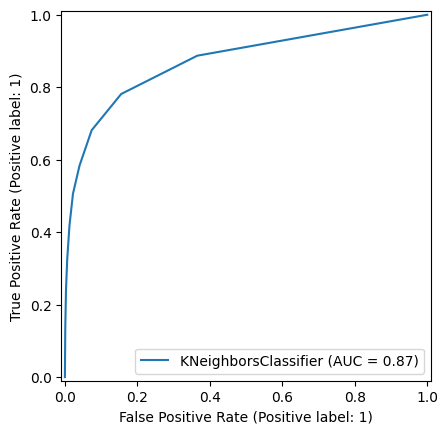

In [9]:
from sklearn.metrics import RocCurveDisplay
#plotting out the roc curve for knn
knn_roc = RocCurveDisplay.from_estimator(knn, X1_test, y_test)


**Seminar 3 page 9**

Instantiares and fits a logistic regression classifier on the trainning data and preforming prediction on test data.

In [10]:
#importing the logisitic regression class
from sklearn.linear_model import LogisticRegression
#insaniate the model
logreg = LogisticRegression()
#fiting out the model on trainning data
logreg.fit(X1_train, y_train)
#performing out the predicions in the test data
y_pred_lr = logreg.predict(X1_test)

**Seminar 3 page 10**

Confusion matrix for the logisitic rgression base learner

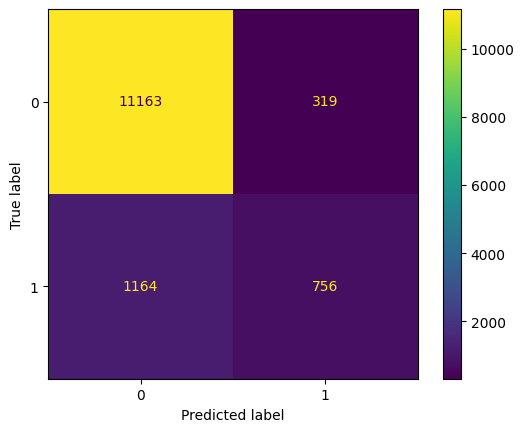

In [11]:




#making the confusion matrix for the logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
#making the display to plotting the confusion matrix
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=logreg.classes_)
disp_lr.plot()

**Seminar 3 page 11**

clasification report for the logisitc regression base learner

In [12]:


#clasification report for the logistic regression
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     11482
           1       0.70      0.39      0.50      1920

    accuracy                           0.89     13402
   macro avg       0.80      0.68      0.72     13402
weighted avg       0.88      0.89      0.88     13402



**Seminar 3 page 11**

Roc curve for the logistic regression base learner

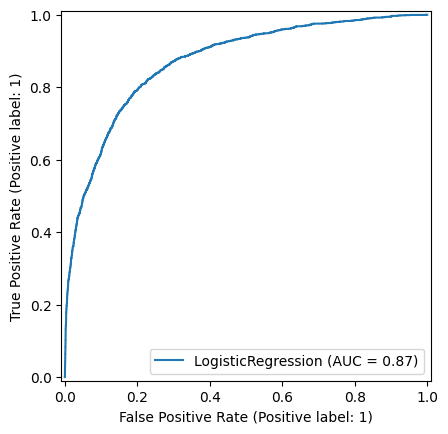

In [13]:
#plotting out ROC curve for logisitic regression
logreg_roc = RocCurveDisplay.from_estimator(logreg, X1_test, y_test)

# voting (soft)
**Seminar 7 page 6**

combining the best performing base learners(logisitic regression, KNN) into a soft voting ensemble classifier using votingClassifier with voting='soft. Fits the ensemble on training data and performs predictions on the test data.

In [14]:
#initiate a new esemble model
from sklearn.ensemble import VotingClassifier
#create a dictonery of our base learners model
base_learners = [('KNN', knn), ('LR', logreg)]
#create our voting classifier, inputing our models
ensemble_learner = VotingClassifier(base_learners, voting='soft')
#fit the model to train data
ensemble_learner = ensemble_learner.fit(X1_train, y_train)
y_pred_ensemble = ensemble_learner.predict(X1_test)

# Ensemble Clasiffier
**Seminar 7 page 7**

Evaluating the confusion matirx for the ensemble model

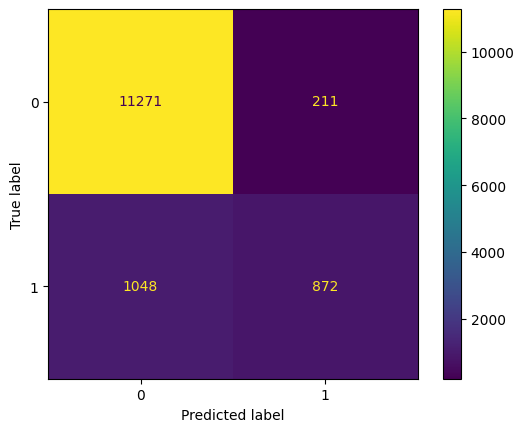

In [15]:
#plotting the confusion metrix for the ensemble model
ensemble_learner_cm = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=ensemble_learner_cm,
                               display_labels=ensemble_learner.classes_)
disp.plot()

**Seminar 7 page 7**

printing the classification report for the ensemble model

In [16]:
#clasification report for the ensemble model
print(classification_report(y_test, y_pred_ensemble))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     11482
           1       0.81      0.45      0.58      1920

    accuracy                           0.91     13402
   macro avg       0.86      0.72      0.76     13402
weighted avg       0.90      0.91      0.89     13402



plots the ROC curve for the ensemble model

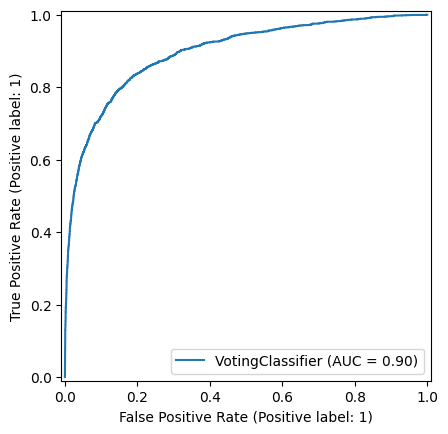

In [17]:
ensemble_roc = RocCurveDisplay.from_estimator(ensemble_learner, X1_test, y_test)

**Seminar 3 page 10**

Comparing the accuracy score of base learners and the ensemble model

In [18]:
from sklearn.metrics import accuracy_score

print('knn Accuracy:', accuracy_score(y_test, y_pred_knn))
print('LR Accuracy:', accuracy_score(y_test, y_pred_lr))
print('ensemble learner Accuracy: ', accuracy_score(y_test, y_pred_ensemble))

knn Accuracy: 0.9101626622892106
LR Accuracy: 0.889344873899418
ensemble learner Accuracy:  0.9060587971944486


# Decision Tree Regression
**Seminar 6 page 4**

Loading the prepared regression  dataset which is created in the notebook 1 into a pandas dataframe calld df_loan_max using pd.read_csv(). this dataset contain only approved applicants

In [19]:
#loading the regression dataset
df_loan_max = pd.read_csv('/content/Prepared_Regression_Dataset.csv')
#printing the first 5 rows of the dataset
df_loan_max.head()




,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_loan_amount(allowed)
0,40.0,4,125000.0,0,1.0,4,21000,6.99,0.17,0,16,21000
1,40.0,4,120000.0,2,4.0,0,20000,15.95,0.17,0,15,20000
2,40.0,4,60000.0,0,13.0,2,20000,14.54,0.33,0,14,20000
3,40.0,4,80000.0,2,10.0,4,20000,18.62,0.25,0,14,20000
4,40.0,4,72000.0,3,3.0,2,20000,13.47,0.28,0,16,20000


In [20]:
#printing the regression dataset shape
print('Regression Dataset Shape:', df_loan_max.shape)

Regression Dataset Shape: (45910, 12)


In [21]:
#printing the columns in the regression dataset
list(df_loan_max.columns)

['age',
 'education_qualifications',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'max_loan_amount(allowed)']

**Seminar 6 page 4**

Displaying the descriptive statistics for the regression dataset.

In [22]:
#checking the descriptive statistics of the regression dataset
df_loan_max.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,45910.0,27.228595,5.764094,20.00,23.00,26.00,29.00,84.00
education_qualifications,45910.0,4.000000,0.000000,4.00,4.00,4.00,4.00,4.00
income,45910.0,59749.032564,22134.667723,4200.00,43000.00,57600.00,74000.00,126000.00
home_ownership,45910.0,1.619756,1.451662,0.00,0.00,2.00,3.00,3.00
employment_length,45910.0,4.736898,3.849437,0.00,2.00,4.00,7.00,150.00
loan_intent,45910.0,2.549052,1.733635,0.00,1.00,3.00,4.00,5.00
loan_amount,45910.0,8233.903442,4419.147687,500.00,5000.00,7500.00,10200.00,22500.00
loan_interest_rate,45910.0,10.233212,2.957316,-11.14,7.51,10.38,12.42,200.00
loan_income_ratio,45910.0,0.146021,0.075427,0.00,0.09,0.13,0.20,0.53
payment_default_on_file,45910.0,0.120889,0.326001,0.00,0.00,0.00,0.00,1.00


**Seminar 6 page 7**

separating the regression dataset into input features X by dropping out the tarfet column Max loan amount asnd assigning the target variable to . Spliting the satasaet into 90% trainning and 10% test subsets using train_test_split() with random_state=10

In [23]:
#assigning input feautres to X except the regression target
X = df_loan_max.drop(['max_loan_amount(allowed)'], axis=1)
#assigning target output to Y
y = df_loan_max['max_loan_amount(allowed)']
#splitting the dataset into trainning and test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.1,
                                                   random_state=10)
#checking the shape of training and test sets
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (41319, 11)
X_test shape: (4591, 11)


**Seminar 6 page 7**

building and fitting a fully grown decision tree with no depth restriction on trainning data using DecisionTreeRegressor(). Performing predictions on the test data and prints the meximum depth of the fully grown tree

In [24]:
#import decision tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn import metrics

#training the decision tree regressor with trainning data
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

#using the predict method
y_pred = regressor.predict(X_test)

#disply th full tree depth
print('the full regression dt levels', regressor.tree_.max_depth)

the full regression dt levels 23


**Seminar 6 page 7**
# DT1 unpruned tree

Genarating the unpruned decision tree and saving in the svg file format

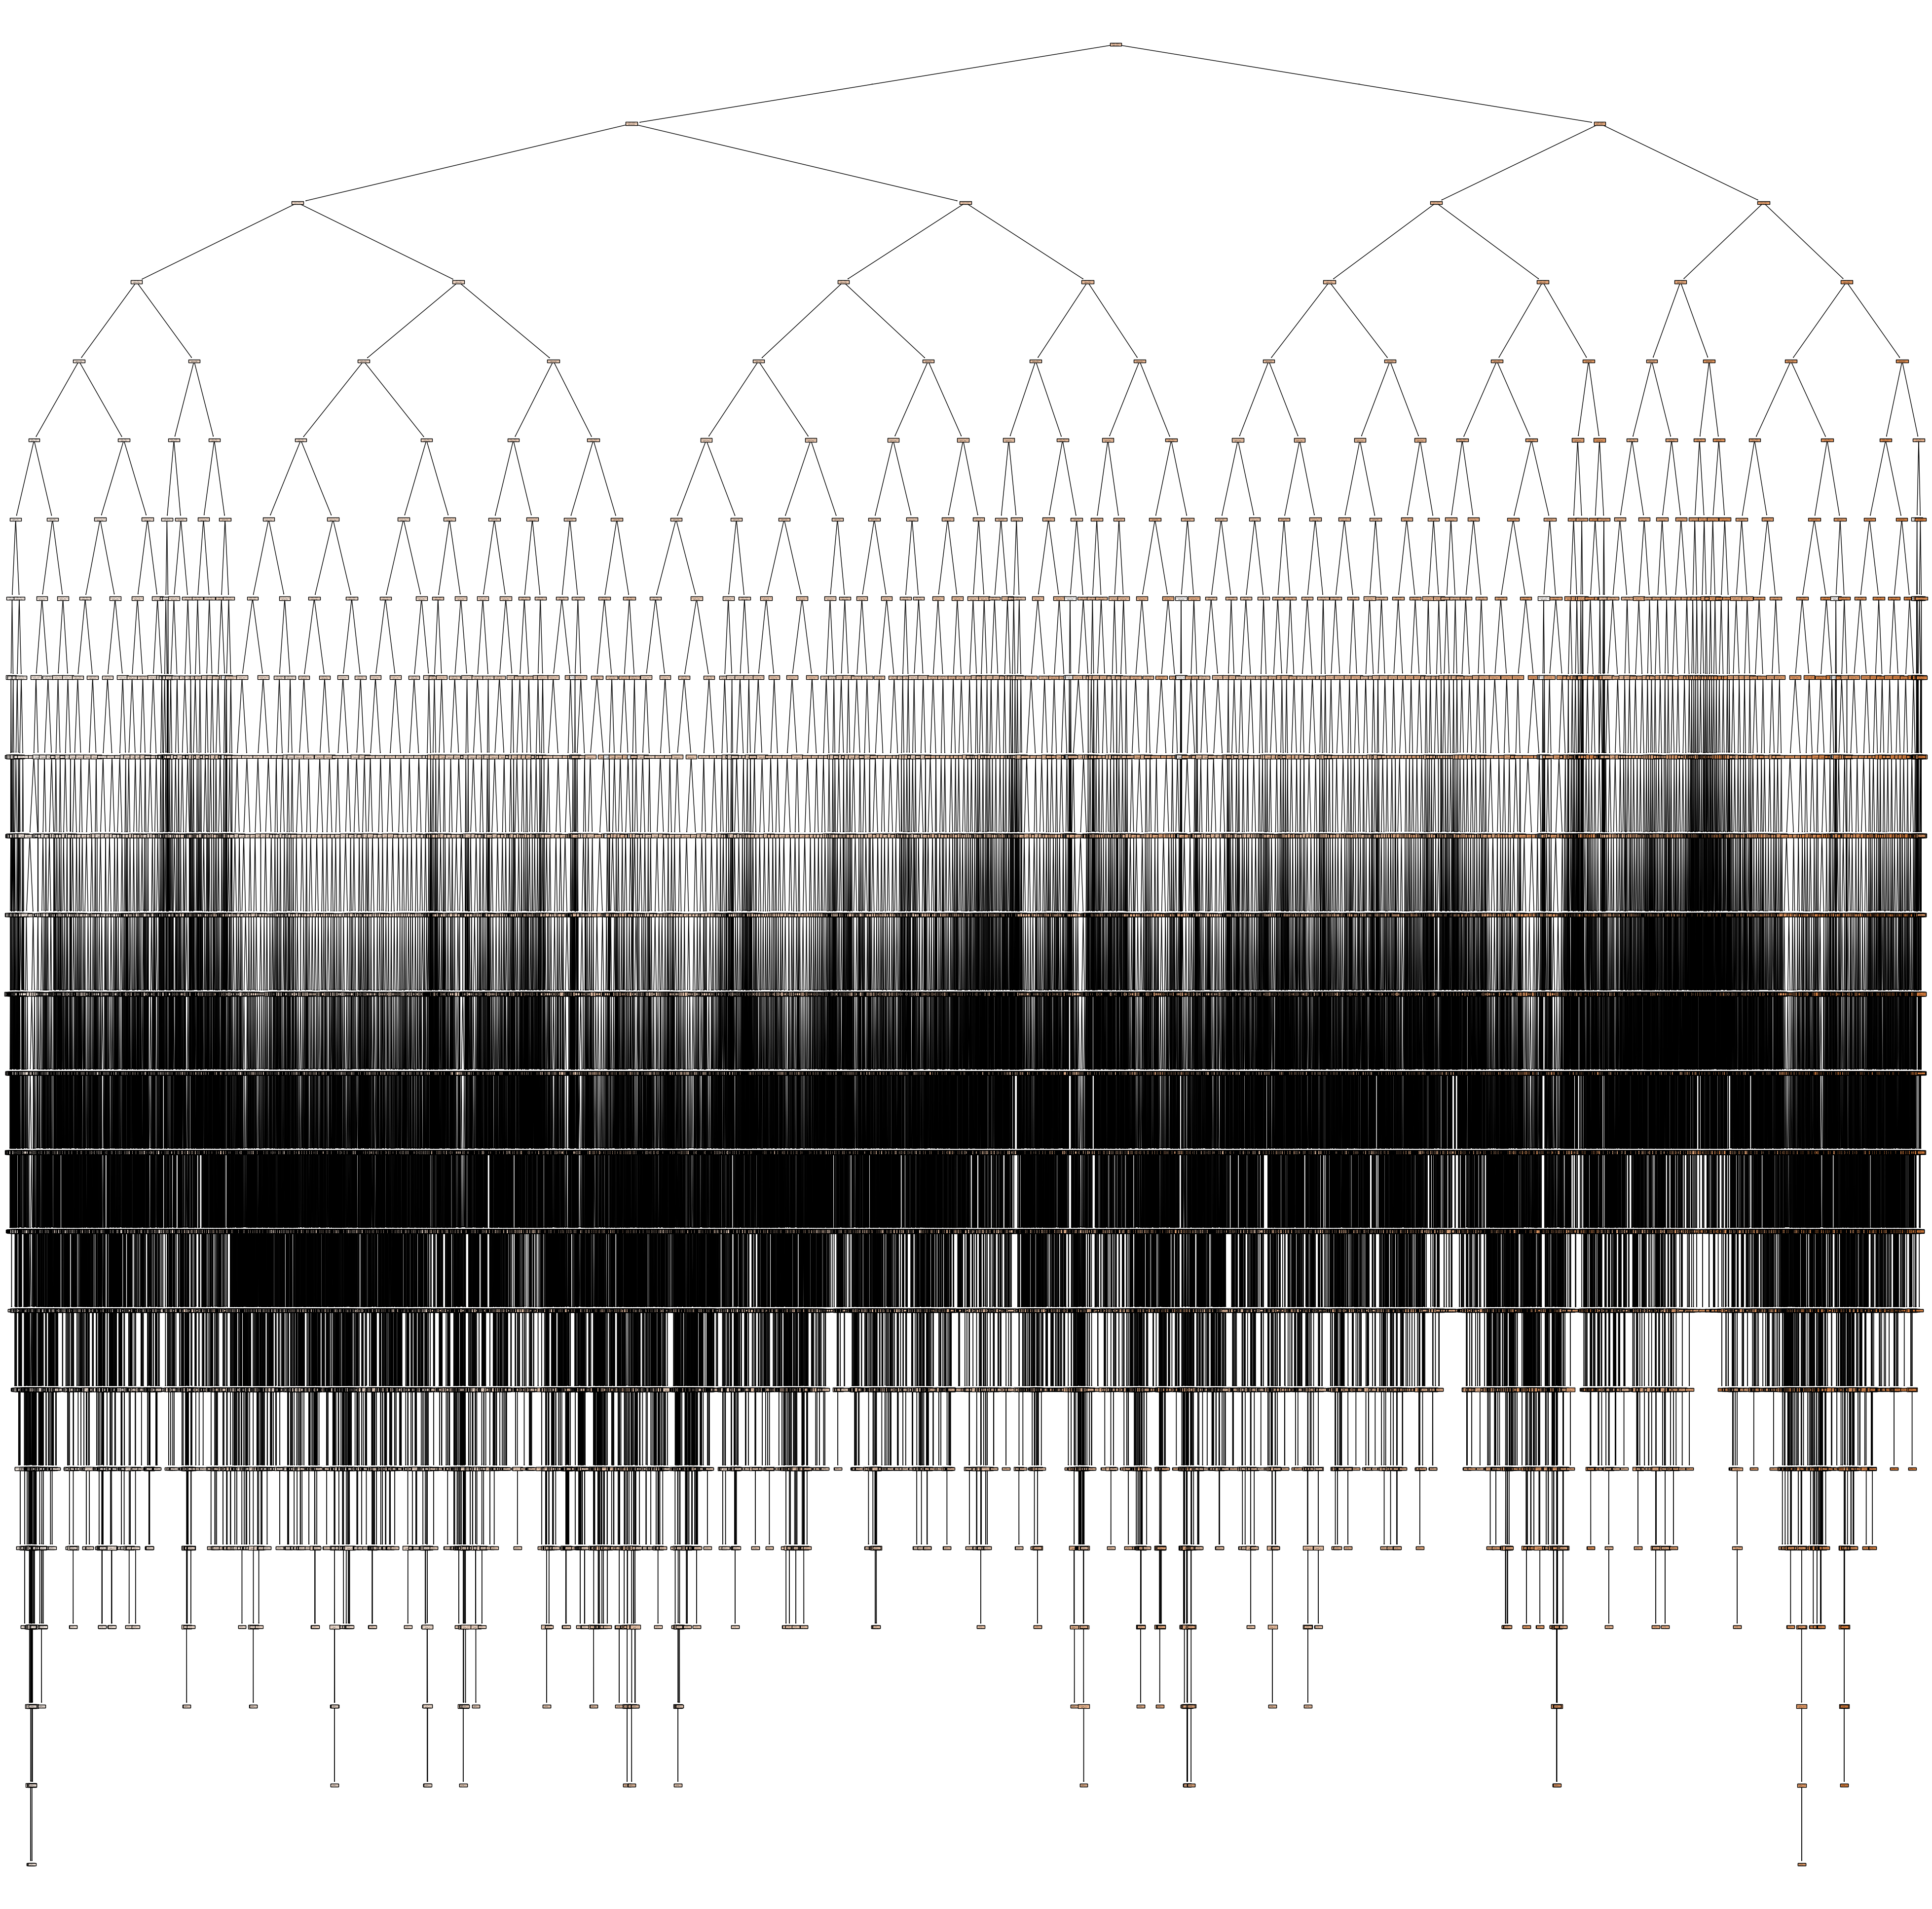

In [25]:
#setting out the siz of the decision tree
Unpruned_Tree_figure = plt.figure(figsize=(50, 50))
DT_Graph = tree.plot_tree(regressor,
                          feature_names=list(X_train.columns),
                          filled=True)
Unpruned_Tree_figure.savefig('fully_grown_reg_decision_tree.svg')

**Seminar 6 page 12**

**DT1 Metrics**

Calculating and printing the performace metrics for the unpruned decision tree

In [26]:
#this prints the average absolute difference between predicted and actual
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
#this prints average squared difference between predicted and actual
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

#this prints proption of variance explained by the model
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 641.6408189936833
Mean Squared Error: 2220333.2409061207
R2: 0.997741324258575


**Seminar 6 page 8**
# DT2 pruned tree

Instatntiares and fit a pruned decision tree limited only for four levels using DecisionTreeRegressor(max_depth=4)

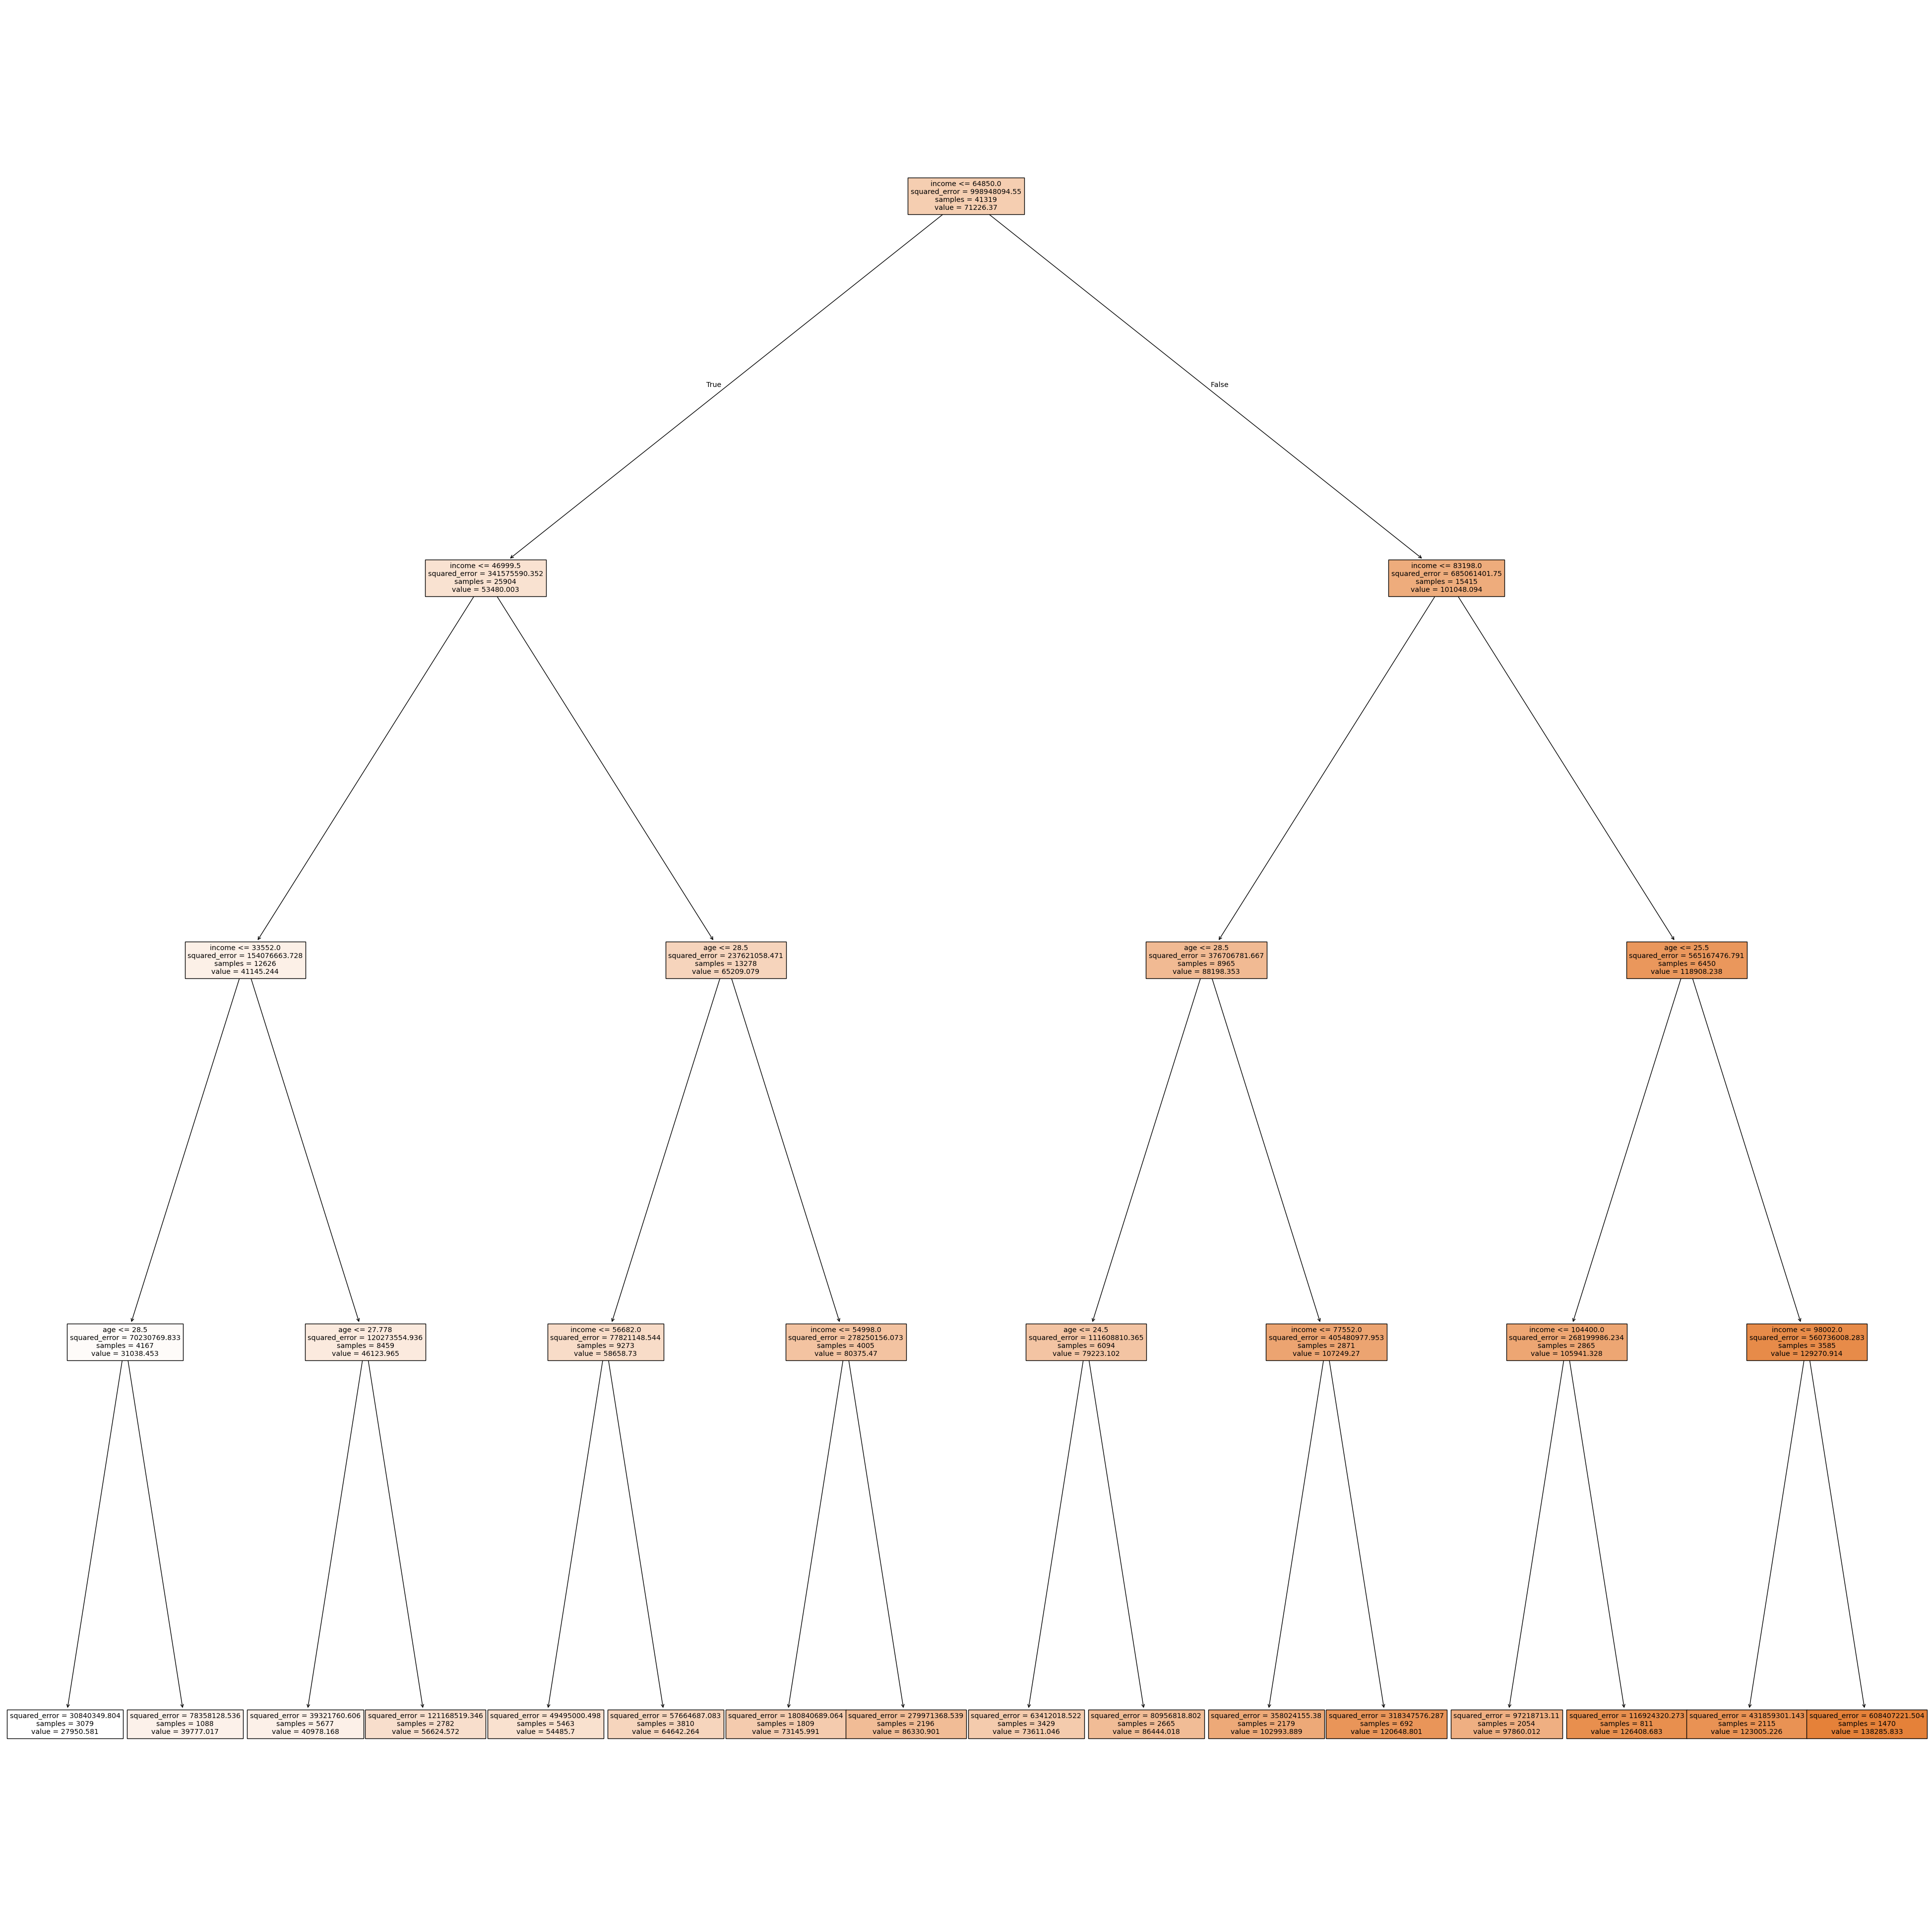

In [27]:
#limiting the tree growth to level 4
pruned_regressor = DecisionTreeRegressor(max_depth=4)
#training the data
pruned_regressor.fit(X_train, y_train)
#making predictions on test
y_pred_pruned = pruned_regressor.predict(X_test)
#ploting the decision tree
pruned_Tree_model = plt.figure(figsize=(50, 50))
pruned_Tree_model_Graph = tree.plot_tree(pruned_regressor,
                                         feature_names=list(X_train.columns),
                                         filled=True)
#saving the decision tree
pruned_Tree_model.savefig('pruned_reg_decision_tree.png')


**Seminar 6 page 12**

**DT2 Metrics**

Calculates and printing the regression performace metrics of the decision tree 2

In [28]:
#printing average absolute difference between predicted and actual
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_pruned))
#printing the average squared difference between predicted and actual
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_pruned))

#printing the proportion of variance explained by the model
print('R2:', metrics.r2_score(y_test, y_pred_pruned))

Mean Absolute Error: 7917.647057624128
Mean Squared Error: 145976734.54196098
R2: 0.8515024217770975


# Comparing both decision trees

Comparing the Performace metrics of both decision trees and identifying the best model

In [29]:
print(' DT1 Unpruned Tree')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

print('R2:', metrics.r2_score(y_test, y_pred))

print(' DT2 Pruned Tree')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_pruned))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_pruned))

print('R2:', metrics.r2_score(y_test, y_pred_pruned))

 DT1 Unpruned Tree
Mean Absolute Error: 641.6408189936833
Mean Squared Error: 2220333.2409061207
R2: 0.997741324258575
 DT2 Pruned Tree
Mean Absolute Error: 7917.647057624128
Mean Squared Error: 145976734.54196098
R2: 0.8515024217770975


# Selecting the best decision tree

In [30]:
#selecting best decision tree model based on R2 score
r2_dt1 = metrics.r2_score(y_test, y_pred)
r2_dt2 = metrics.r2_score(y_test, y_pred_pruned)
if r2_dt1 > r2_dt2:
      print('Best model DT1 fully grown:', r2_dt1)
else:
      print('Best model DT2 pruned tree:', r2_dt2)

Best model DT1 fully grown: 0.997741324258575


# Predict maximum loan amount for a new applicant

Seminar 7 page 12

In [31]:
data = []
#adding client attribute values based on the report
data.append({
    'age': 56,
    'education_qualifications': 4,
    'income': 57000,
    'home_ownership': 3,
    'employment_length': 15,
    'loan_intent': 3,
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 0,
    'credit_history_length': 35
      })
#create a dataframe for the client attribute values
df_client_60256 = pd.DataFrame(data)
#using dt1 to predict the maximum loan amount
df_client_60256['Predicted Maximum Loan Amount'] = regressor.predict(df_client_60256)
df_client_60256.head()

,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,Predicted Maximum Loan Amount
0,56,4,57000,3,15,3,25700,23.0,0.1,0,35,97996.0
